In [2]:
# PART 1: Setup and Path Verification
# Run this first to ensure everything is configured correctly

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*60)
print("PART 1: SETUP AND PATH VERIFICATION")
print("="*60)

# Define your dataset path - UPDATE THIS TO YOUR ACTUAL PATH
# Examples:
# DATA_PATH = "./lung_ultrasound_dataset"  # If in current folder
# DATA_PATH = "C:/Users/YourName/Downloads/lung_ultrasound_dataset"  # Windows
# DATA_PATH = "/home/username/Downloads/lung_ultrasound_dataset"  # Linux/Mac
DATA_PATH = r"C:\Users\Administrator\Documents\dataset"  # <-- CHANGE THIS

print(f"\nChecking path: {DATA_PATH}")

# Check if path exists
if not os.path.exists(DATA_PATH):
    print(f"❌ ERROR: Path does not exist!")
    print("\nPlease update DATA_PATH to the correct location.")
    print("\nCurrent directory:", os.getcwd())
    print("\nFiles in current directory:")
    for item in os.listdir('.'):
        print(f"  • {item}")
else:
    print(f"✅ Path exists!")
    
    # Check for train/test/eval folders
    data_path = Path(DATA_PATH)
    splits_found = []
    
    for split in ['train', 'test', 'validation']:
        split_path = data_path / split
        if split_path.exists():
            splits_found.append(split)
            print(f"✅ Found '{split}' folder")
        else:
            print(f"❌ No '{split}' folder found")
    
    if splits_found:
        print(f"\n📁 Available splits: {splits_found}")
        
        # Show first few files in train folder if it exists
        if 'train' in splits_found:
            train_path = data_path / 'train'
            class_folders = [d for d in train_path.iterdir() if d.is_dir()]
            print(f"\n📂 Classes in train folder: {[c.name for c in class_folders]}")
            
            if class_folders:
                first_class = class_folders[0]
                images = list(first_class.glob('*.jpg')) + list(first_class.glob('*.png'))
                print(f"  Example: '{first_class.name}' contains {len(images)} images")
                if images:
                    print(f"  First image: {images[0].name}")
    else:
        print("\n❌ No train/test/eval folders found!")
        print("Please check if you've extracted the dataset correctly.")

PART 1: SETUP AND PATH VERIFICATION

Checking path: C:\Users\Administrator\Documents\dataset
✅ Path exists!
✅ Found 'train' folder
✅ Found 'test' folder
✅ Found 'validation' folder

📁 Available splits: ['train', 'test', 'validation']

📂 Classes in train folder: ['covid', 'healthy', 'other']
  Example: 'covid' contains 170 images
  First image: 1646466936258.png


In [3]:
# PART 2: Helper Functions for Image Analysis
# Run this after Part 1 to define all necessary functions

print("="*60)
print("PART 2: DEFINING HELPER FUNCTIONS")
print("="*60)

def get_class_distribution(split_path):
    """
    Get class distribution from folder structure
    Assumes: split_path/class_name/*.jpg or *.png
    """
    if not split_path.exists():
        return None, 0
    
    distribution = {}
    total_images = 0
    
    # Get all class folders
    class_folders = [d for d in split_path.iterdir() if d.is_dir()]
    
    if not class_folders:
        print(f"  ⚠️ No class folders found in {split_path}")
        return {}, 0
    
    for class_folder in class_folders:
        class_name = class_folder.name
        # Count images in this class folder
        image_files = list(class_folder.glob('*.jpg')) + \
                     list(class_folder.glob('*.jpeg')) + \
                     list(class_folder.glob('*.png'))
        count = len(image_files)
        distribution[class_name] = count
        total_images += count
    
    return distribution, total_images


def analyze_single_image_properties(img_path):
    """
    Analyze properties of a single image
    """
    try:
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            return None
        
        h, w = img.shape
        
        properties = {
            'brightness': float(np.mean(img)),
            'contrast': float(np.std(img)),
            'height': h,
            'width': w,
            'resolution': h * w,
            'aspect_ratio': w / h,
            'filename': img_path.name,
            'class': img_path.parent.name  # Get class from parent folder name
        }
        
        return properties
    except Exception as e:
        print(f"  ⚠️ Error reading {img_path.name}: {e}")
        return None


def analyze_split_properties(split_path, max_samples=100):
    """
    Analyze image properties from a split
    """
    if not split_path.exists():
        return None
    
    # Get all image files from all class folders
    all_images = []
    for class_folder in split_path.iterdir():
        if class_folder.is_dir():
            all_images.extend(class_folder.glob('*.jpg'))
            all_images.extend(class_folder.glob('*.jpeg'))
            all_images.extend(class_folder.glob('*.png'))
    
    if not all_images:
        print(f"  ⚠️ No images found in {split_path}")
        return None
    
    print(f"  Found {len(all_images)} total images")
    
    # Sample if too many
    if len(all_images) > max_samples:
        all_images = np.random.choice(all_images, max_samples, replace=False)
        print(f"  Analyzing {max_samples} sampled images...")
    else:
        print(f"  Analyzing all {len(all_images)} images...")
    
    # Analyze each image
    properties_list = []
    for img_path in all_images:
        props = analyze_single_image_properties(img_path)
        if props:
            properties_list.append(props)
    
    # Convert to DataFrame for easier analysis
    if properties_list:
        df = pd.DataFrame(properties_list)
        return df
    else:
        return None


def print_distribution_summary(distribution, total, split_name):
    """
    Print formatted class distribution
    """
    print(f"\n  📊 {split_name.capitalize()} Split Distribution:")
    print(f"     Total images: {total}")
    for class_name, count in distribution.items():
        pct = (count / total) * 100 if total > 0 else 0
        bar = '█' * int(pct / 5)  # Simple bar visualization
        print(f"     • {class_name:<20}: {count:4d} ({pct:5.1f}%) {bar}")

print("\n✅ Helper functions defined successfully!")

PART 2: DEFINING HELPER FUNCTIONS

✅ Helper functions defined successfully!


In [4]:
# PART 3: Analyze Training Split
# Run this after Part 2 to analyze your training data

print("="*60)
print("PART 3: ANALYZING TRAINING SPLIT")
print("="*60)

# Use the DATA_PATH from Part 1
data_path = Path(DATA_PATH)
train_path = data_path / 'train'

if not train_path.exists():
    print(f"❌ Train folder not found at: {train_path}")
    print("Please check your DATA_PATH in Part 1")
else:
    print(f"✅ Found train folder: {train_path}")
    
    # 3.1: Get class distribution
    print("\n--- 3.1: Class Distribution ---")
    train_distribution, train_total = get_class_distribution(train_path)
    
    if train_distribution:
        print_distribution_summary(train_distribution, train_total, 'train')
        
        # Calculate imbalance ratio
        counts = list(train_distribution.values())
        if len(counts) > 1:
            imbalance = max(counts) / min(counts)
            print(f"\n     Imbalance ratio (max/min): {imbalance:.2f}")
            if imbalance > 2:
                print("     ⚠️ Significant class imbalance detected!")
    else:
        print("❌ Could not get class distribution")
    
    # 3.2: Analyze image properties
    print("\n--- 3.2: Image Properties Analysis ---")
    train_df = analyze_split_properties(train_path, max_samples=200)
    
    if train_df is not None and len(train_df) > 0:
        print(f"\n  ✅ Analyzed {len(train_df)} images")
        
        # Summary statistics
        print("\n  📊 Image Properties Summary:")
        for col in ['brightness', 'contrast', 'resolution', 'aspect_ratio']:
            if col in train_df.columns:
                mean_val = train_df[col].mean()
                std_val = train_df[col].std()
                min_val = train_df[col].min()
                max_val = train_df[col].max()
                print(f"     • {col.capitalize():<12}: "
                      f"mean={mean_val:.1f} ± {std_val:.1f}, "
                      f"range=[{min_val:.1f}, {max_val:.1f}]")
        
        # Check for resolution consistency
        unique_resolutions = train_df.groupby(['height', 'width']).size().reset_index(name='count')
        if len(unique_resolutions) > 1:
            print(f"\n  📏 Multiple resolutions detected ({len(unique_resolutions)} unique):")
            for _, row in unique_resolutions.iterrows():
                print(f"     • {int(row['height'])}x{int(row['width'])}: {row['count']} images")
        else:
            print(f"\n  ✓ All images have same resolution: "
                  f"{int(train_df['height'].iloc[0])}x{int(train_df['width'].iloc[0])}")
        
        # Save for later use
        train_analysis = {
            'distribution': train_distribution,
            'total': train_total,
            'dataframe': train_df
        }
    else:
        print("❌ Could not analyze image properties")
        train_analysis = None

PART 3: ANALYZING TRAINING SPLIT
✅ Found train folder: C:\Users\Administrator\Documents\dataset\train

--- 3.1: Class Distribution ---

  📊 Train Split Distribution:
     Total images: 723
     • covid               :  241 ( 33.3%) ██████
     • healthy             :  241 ( 33.3%) ██████
     • other               :  241 ( 33.3%) ██████

     Imbalance ratio (max/min): 1.00

--- 3.2: Image Properties Analysis ---
  Found 723 total images
  Analyzing 200 sampled images...

  ✅ Analyzed 200 images

  📊 Image Properties Summary:
     • Brightness  : mean=32.7 ± 16.1, range=[10.7, 83.4]
     • Contrast    : mean=36.4 ± 9.6, range=[19.2, 67.9]
     • Resolution  : mean=227178.0 ± 86249.9, range=[49220.0, 359100.0]
     • Aspect_ratio: mean=0.9 ± 0.2, range=[0.6, 1.5]

  📏 Multiple resolutions detected (114 unique):
     • 230x214: 1 images
     • 245x244: 1 images
     • 266x332: 1 images
     • 279x340: 1 images
     • 280x364: 1 images
     • 289x322: 1 images
     • 291x378: 1 images
   

In [6]:
# PART 4: Analyze Test and Eval Splits
# Run this after Part 3

print("="*60)
print("PART 4: ANALYZING TEST AND EVAL SPLITS")
print("="*60)

data_path = Path(DATA_PATH)
test_path = data_path / 'test'
eval_path = data_path / 'validation'

# Dictionary to store all split analyses
all_splits = {}

# 4.1: Analyze Test Split
print("\n--- 4.1: Test Split Analysis ---")
if test_path.exists():
    print(f"✅ Found test folder: {test_path}")
    
    test_distribution, test_total = get_class_distribution(test_path)
    if test_distribution:
        print_distribution_summary(test_distribution, test_total, 'test')
        
        test_df = analyze_split_properties(test_path, max_samples=100)
        
        if test_df is not None:
            print(f"\n  ✅ Analyzed {len(test_df)} test images")
            
            all_splits['test'] = {
                'distribution': test_distribution,
                'total': test_total,
                'dataframe': test_df
            }
else:
    print("ℹ️ No test folder found (this is OK if your dataset doesn't have one)")

# 4.2: Analyze Eval Split
print("\n--- 4.2: Eval Split Analysis ---")
if eval_path.exists():
    print(f"✅ Found eval folder: {eval_path}")
    
    eval_distribution, eval_total = get_class_distribution(eval_path)
    if eval_distribution:
        print_distribution_summary(eval_distribution, eval_total, 'eval')
        
        eval_df = analyze_split_properties(eval_path, max_samples=100)
        
        if eval_df is not None:
            print(f"\n  ✅ Analyzed {len(eval_df)} eval images")
            
            all_splits['eval'] = {
                'distribution': eval_distribution,
                'total': eval_total,
                'dataframe': eval_df
            }
else:
    print("ℹ️ No eval folder found (this is OK if your dataset doesn't have one)")

# Add train split to all_splits if it exists
if 'train_analysis' in locals() and train_analysis is not None:
    all_splits['train'] = train_analysis

PART 4: ANALYZING TEST AND EVAL SPLITS

--- 4.1: Test Split Analysis ---
✅ Found test folder: C:\Users\Administrator\Documents\dataset\test

  📊 Test Split Distribution:
     Total images: 141
     • covid               :   31 ( 22.0%) ████
     • healthy             :   55 ( 39.0%) ███████
     • other               :   55 ( 39.0%) ███████
  Found 141 total images
  Analyzing 100 sampled images...

  ✅ Analyzed 100 test images

--- 4.2: Eval Split Analysis ---
✅ Found eval folder: C:\Users\Administrator\Documents\dataset\validation

  📊 Eval Split Distribution:
     Total images: 198
     • covid               :   66 ( 33.3%) ██████
     • healthy             :   66 ( 33.3%) ██████
     • other               :   66 ( 33.3%) ██████
  Found 198 total images
  Analyzing 100 sampled images...

  ✅ Analyzed 100 eval images


PART 5: CROSS-SPLIT COMPARISON
Comparing 3 splits: ['test', 'eval', 'train']

--- 5.1: Class Distribution Comparison ---

Class Distribution (%) by Split:
----------------------------------------------------------------------
Class                       Test        Eval       Train    Max Diff
----------------------------------------------------------------------
covid                      22.0%       33.3%       33.3%       11.3% ⚠️
healthy                    39.0%       33.3%       33.3%        5.7% ⚠️
other                      39.0%       33.3%       33.3%        5.7% ⚠️

📊 Comparison DataFrame:
     class       test       eval      train   max_diff
0    covid  21.985816  33.333333  33.333333  11.347518
1  healthy  39.007092  33.333333  33.333333   5.673759
2    other  39.007092  33.333333  33.333333   5.673759

--- 5.2: Creating Comparison Visualization ---


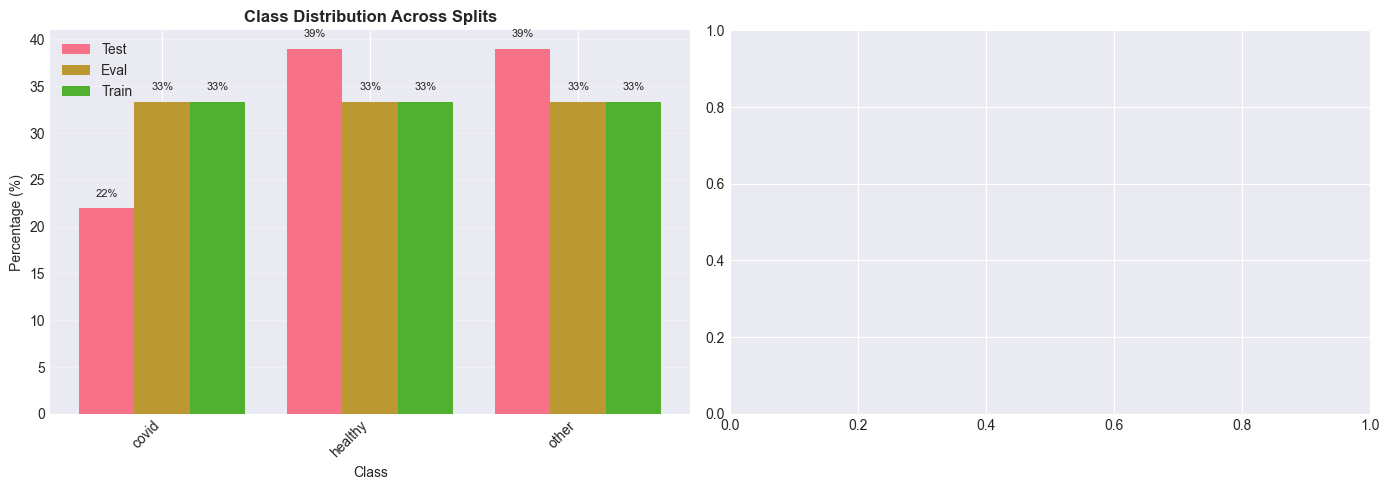

✅ Saved: split_comparison.png


In [7]:
# PART 5: Cross-Split Comparison
# Run this after Part 4

print("="*60)
print("PART 5: CROSS-SPLIT COMPARISON")
print("="*60)

if len(all_splits) < 2:
    print("⚠️ Need at least 2 splits for comparison")
else:
    print(f"Comparing {len(all_splits)} splits: {list(all_splits.keys())}")
    
    # 5.1: Compare class distributions
    print("\n--- 5.1: Class Distribution Comparison ---")
    
    # Get all unique classes
    all_classes = set()
    for split_name, split_data in all_splits.items():
        all_classes.update(split_data['distribution'].keys())
    all_classes = sorted(list(all_classes))
    
    # Create comparison table
    print("\nClass Distribution (%) by Split:")
    print("-" * 70)
    header = f"{'Class':<20}"
    for split_name in all_splits.keys():
        header += f"{split_name.capitalize():>12}"
    header += f"{'Max Diff':>12}"
    print(header)
    print("-" * 70)
    
    comparison_data = []
    
    for class_name in all_classes:
        row = {'class': class_name}
        percentages = []
        
        for split_name, split_data in all_splits.items():
            count = split_data['distribution'].get(class_name, 0)
            pct = (count / split_data['total']) * 100 if split_data['total'] > 0 else 0
            row[split_name] = pct
            percentages.append(pct)
        
        max_diff = max(percentages) - min(percentages) if len(percentages) > 1 else 0
        row['max_diff'] = max_diff
        
        # Print row
        line = f"{class_name:<20}"
        for split_name in all_splits.keys():
            line += f"{row[split_name]:>11.1f}%"
        line += f"{max_diff:>11.1f}%"
        
        if max_diff > 5:
            line += " ⚠️"
        
        print(line)
        comparison_data.append(row)
    
    # Create DataFrame for easy viewing
    comparison_df = pd.DataFrame(comparison_data)
    print("\n📊 Comparison DataFrame:")
    print(comparison_df)
    
    # 5.2: Visual comparison
    print("\n--- 5.2: Creating Comparison Visualization ---")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar plot comparison
    ax = axes[0]
    x = np.arange(len(all_classes))
    width = 0.8 / len(all_splits)
    
    for i, (split_name, split_data) in enumerate(all_splits.items()):
        percentages = []
        for class_name in all_classes:
            count = split_data['distribution'].get(class_name, 0)
            pct = (count / split_data['total']) * 100
            percentages.append(pct)
        
        offset = (i - len(all_splits)/2 + 0.5) * width
        bars = ax.bar(x + offset, percentages, width, label=split_name.capitalize())
        
        # Add value labels
        for bar, pct in zip(bars, percentages):
            if pct > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                       f'{pct:.0f}%', ha='center', va='bottom', fontsize=8)
    
    ax.set_xlabel('Class')
    ax.set_ylabel('Percentage (%)')
    ax.set_title('Class Distribution Across Splits', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(all_classes, rotation=45, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # Heatmap of differences
    ax = axes[1]
    if len(all_splits) == 2:
        # Simple difference heatmap
        split1, split2 = list(all_splits.keys())[:2]
        diff_values = []
        for class_name in all_classes:
            pct1 = comparison_df.loc[comparison_df['class'] == class_name, split1].values[0]
            pct2 = comparison_df.loc[comparison_df['class'] == class_name, split2].values[0]
            diff_values.append(pct1 - pct2)
        
        diff_matrix = np.array(diff_values).reshape(-1, 1)
        im = ax.imshow(diff_matrix, cmap='RdBu_r', aspect='auto', vmin=-10, vmax=10)
        ax.set_yticks(range(len(all_classes)))
        ax.set_yticklabels(all_classes)
        ax.set_xticks([0])
        ax.set_xticklabels([f'{split1} - {split2}'])
        ax.set_title('Class Distribution Difference', fontweight='bold')
        plt.colorbar(im, ax=ax, label='Percentage Difference')
    
    plt.tight_layout()
    plt.savefig('split_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Saved: split_comparison.png")

PART 6: GENERATING VISUALIZATIONS

--- 6.1: Class Distribution Bar Chart ---


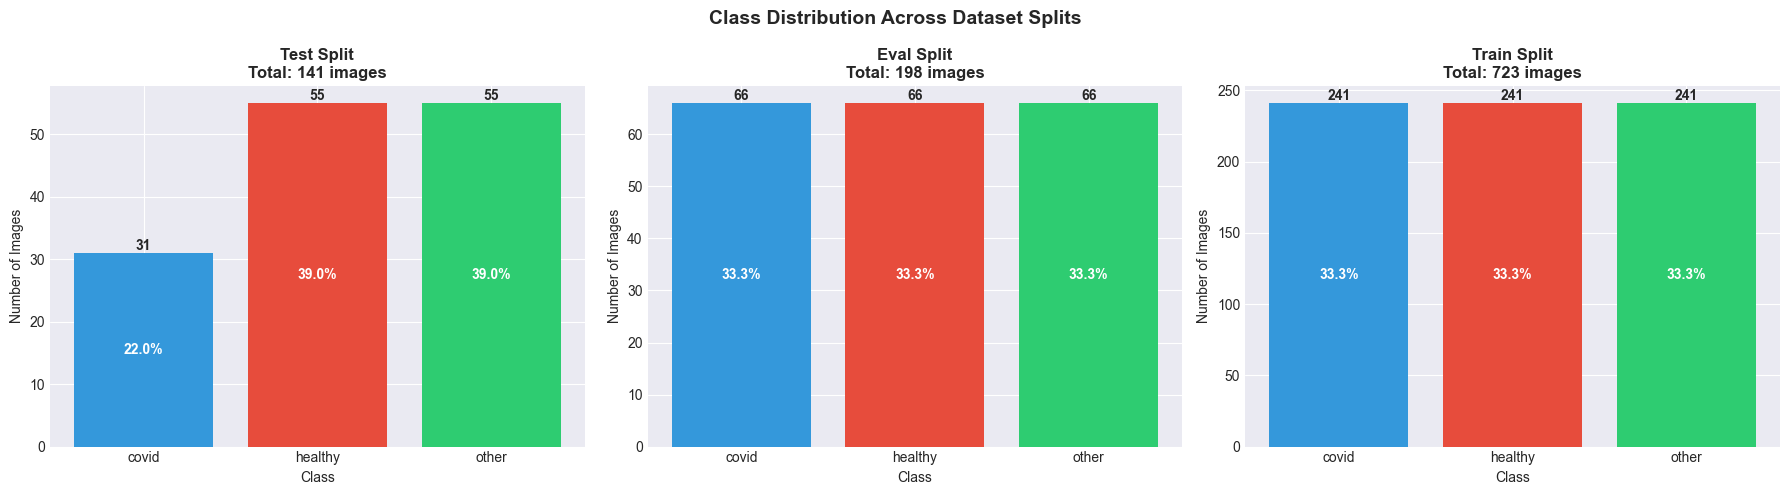

✅ Saved: class_distribution_detailed.png

--- 6.2: Image Properties Histograms ---


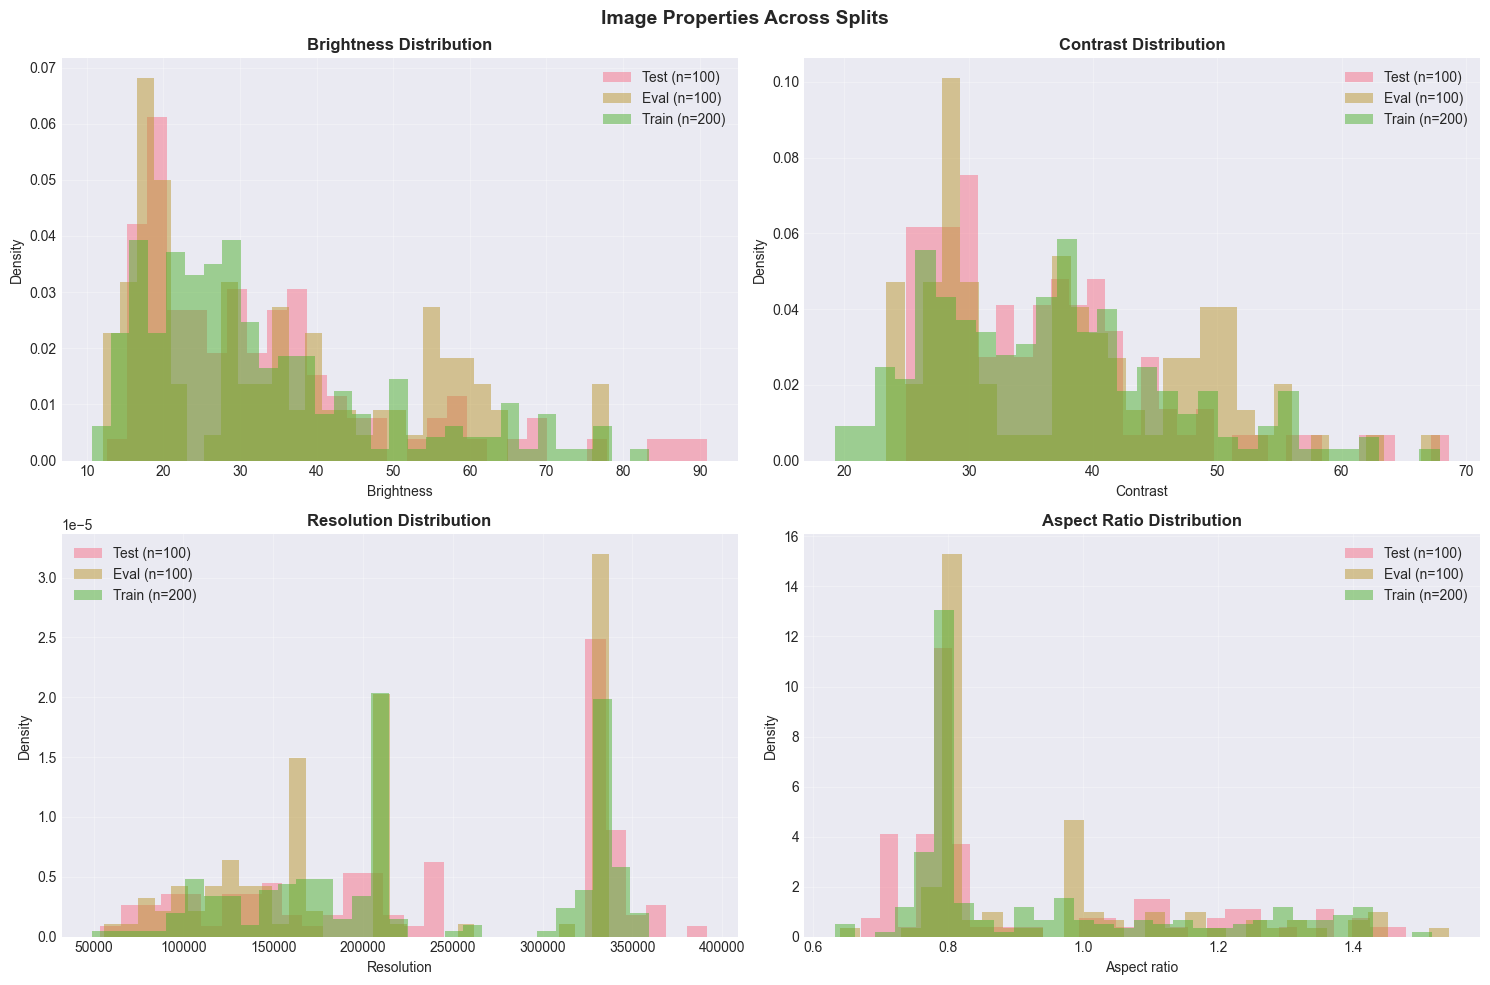

✅ Saved: image_properties_histograms.png

--- 6.3: Box Plots by Class (Training Data) ---


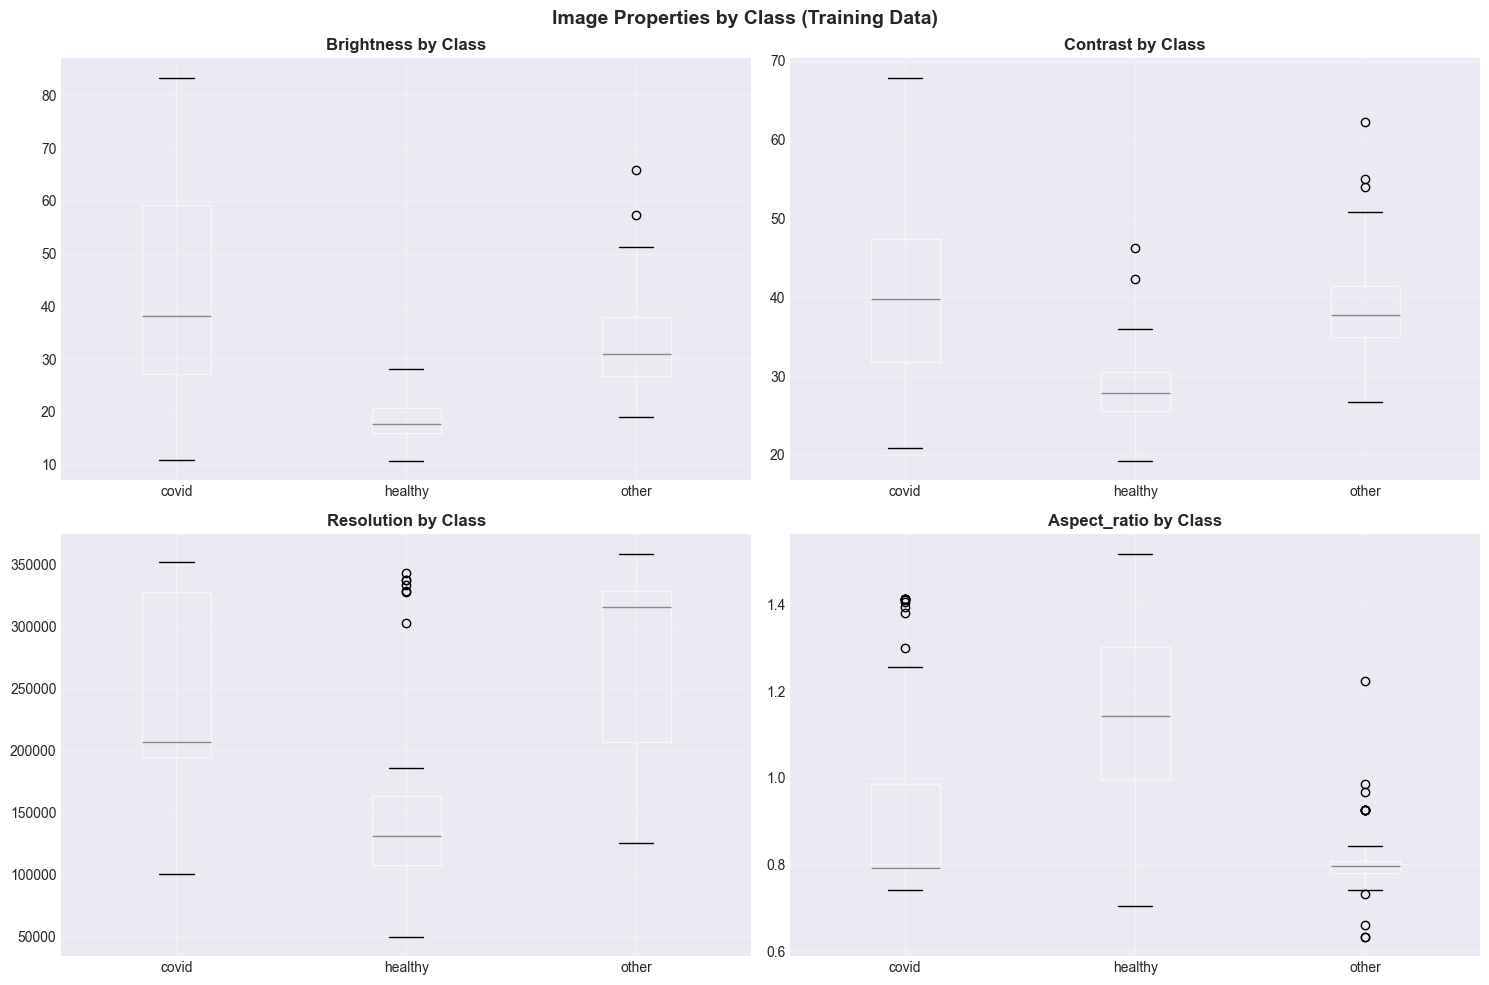

✅ Saved: properties_by_class.png

--- 6.4: Sample Images from Each Class ---


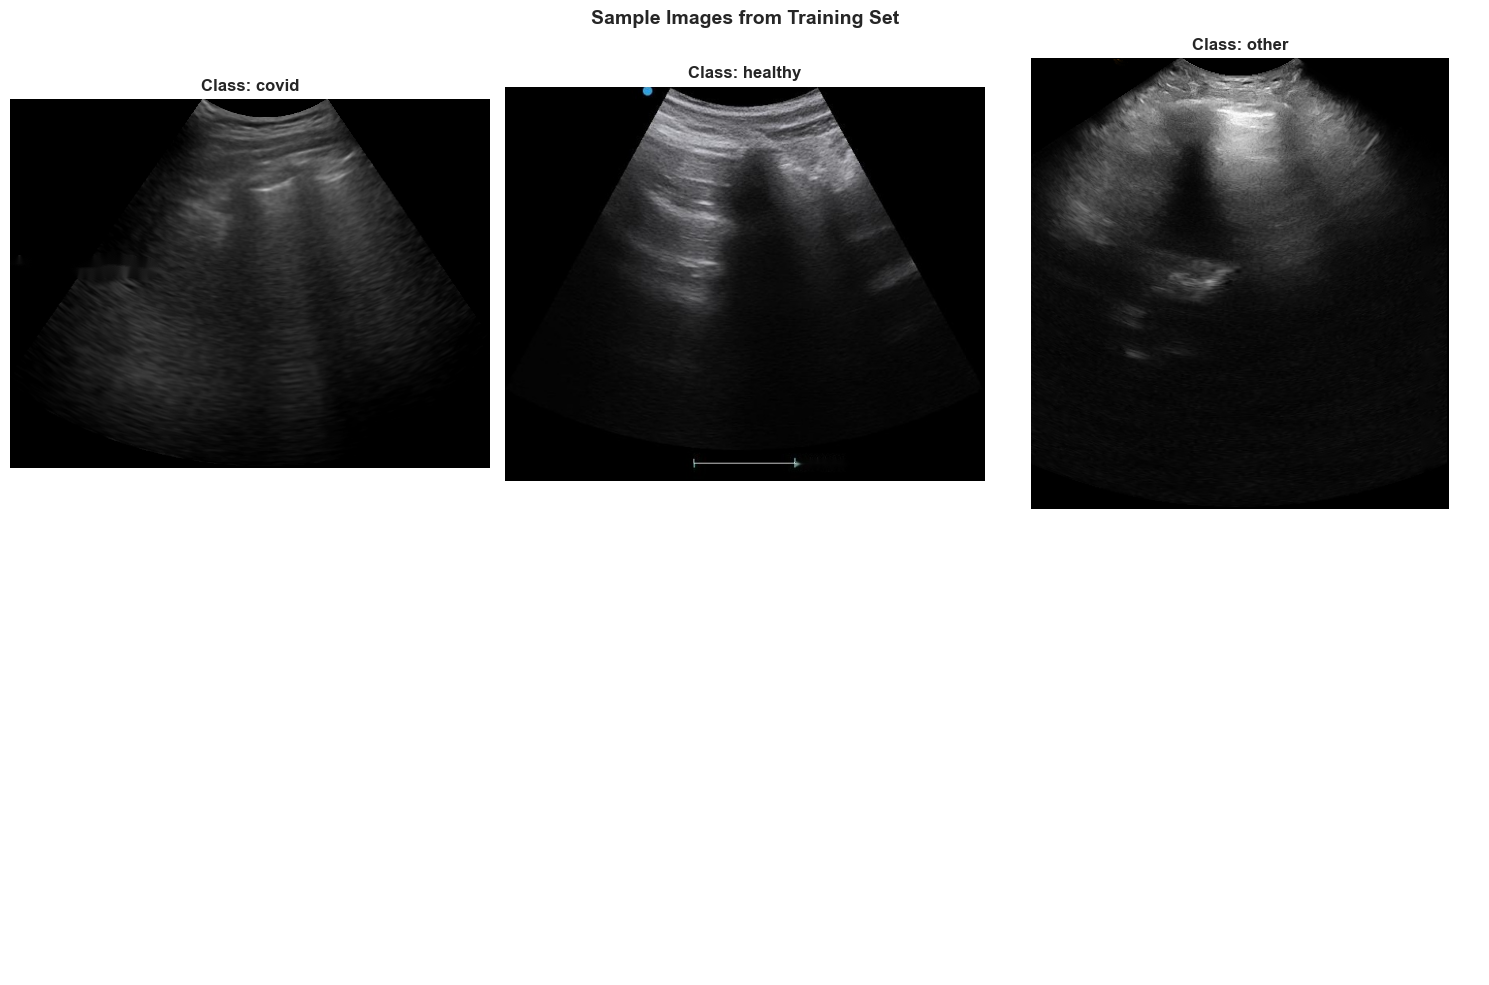

✅ Saved: sample_images.png


In [8]:
# PART 6: Generate Visualizations
# Run this after Part 5

print("="*60)
print("PART 6: GENERATING VISUALIZATIONS")
print("="*60)

if not all_splits:
    print("❌ No data available for visualization")
else:
    # 6.1: Class Distribution Bar Chart
    print("\n--- 6.1: Class Distribution Bar Chart ---")
    
    n_splits = len(all_splits)
    fig, axes = plt.subplots(1, n_splits, figsize=(6*n_splits, 5))
    if n_splits == 1:
        axes = [axes]
    
    colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
    
    for idx, (split_name, split_data) in enumerate(all_splits.items()):
        ax = axes[idx]
        classes = list(split_data['distribution'].keys())
        counts = list(split_data['distribution'].values())
        
        bars = ax.bar(classes, counts, color=colors[:len(classes)])
        ax.set_title(f'{split_name.capitalize()} Split\nTotal: {split_data["total"]} images', 
                    fontweight='bold', fontsize=12)
        ax.set_xlabel('Class')
        ax.set_ylabel('Number of Images')
        
        # Add value labels
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(height)}', ha='center', va='bottom', fontweight='bold')
        
        # Add percentage labels
        for bar, count in zip(bars, counts):
            pct = (count / split_data['total']) * 100
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height()/2,
                   f'{pct:.1f}%', ha='center', va='center', color='white', fontweight='bold')
    
    plt.suptitle('Class Distribution Across Dataset Splits', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('class_distribution_detailed.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Saved: class_distribution_detailed.png")
    
    # 6.2: Image Properties Histograms
    print("\n--- 6.2: Image Properties Histograms ---")
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    metrics = ['brightness', 'contrast', 'resolution', 'aspect_ratio']
    titles = ['Brightness Distribution', 'Contrast Distribution', 
              'Resolution Distribution', 'Aspect Ratio Distribution']
    
    for idx, (metric, title) in enumerate(zip(metrics, titles)):
        row, col = idx // 2, idx % 2
        ax = axes[row, col]
        
        has_data = False
        for split_name, split_data in all_splits.items():
            if 'dataframe' in split_data and split_data['dataframe'] is not None:
                df = split_data['dataframe']
                if metric in df.columns:
                    ax.hist(df[metric], alpha=0.5, bins=30, 
                           label=f"{split_name.capitalize()} (n={len(df)})", 
                           density=True)
                    has_data = True
        
        if has_data:
            ax.set_title(title, fontweight='bold')
            ax.set_xlabel(metric.replace('_', ' ').capitalize())
            ax.set_ylabel('Density')
            ax.legend()
            ax.grid(True, alpha=0.3)
        else:
            ax.text(0.5, 0.5, f'No {metric} data', 
                   ha='center', va='center', transform=ax.transAxes)
    
    plt.suptitle('Image Properties Across Splits', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('image_properties_histograms.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Saved: image_properties_histograms.png")
    
    # 6.3: Box Plots by Class
    print("\n--- 6.3: Box Plots by Class (Training Data) ---")
    
    if 'train' in all_splits and 'dataframe' in all_splits['train']:
        train_df = all_splits['train']['dataframe']
        
        if 'class' in train_df.columns:
            fig, axes = plt.subplots(2, 2, figsize=(15, 10))
            metrics = ['brightness', 'contrast', 'resolution', 'aspect_ratio']
            
            for idx, metric in enumerate(metrics):
                row, col = idx // 2, idx % 2
                ax = axes[row, col]
                
                # Create box plot
                train_df.boxplot(column=metric, by='class', ax=ax)
                ax.set_title(f'{metric.capitalize()} by Class', fontweight='bold')
                ax.set_xlabel('')
                ax.grid(True, alpha=0.3)
            
            plt.suptitle('Image Properties by Class (Training Data)', fontsize=14, fontweight='bold')
            plt.tight_layout()
            plt.savefig('properties_by_class.png', dpi=300, bbox_inches='tight')
            plt.show()
            print("✅ Saved: properties_by_class.png")
    
    # 6.4: Sample Images Visualization
    print("\n--- 6.4: Sample Images from Each Class ---")
    
    if 'train' in all_splits and train_path.exists():
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes = axes.flatten()
        
        # Get one sample image from each class
        class_folders = [d for d in train_path.iterdir() if d.is_dir()]
        sample_images = []
        
        for class_folder in class_folders:
            images = list(class_folder.glob('*.jpg')) + list(class_folder.glob('*.png'))
            if images:
                sample_images.append((class_folder.name, images[0]))
        
        for idx, (class_name, img_path) in enumerate(sample_images[:6]):
            if idx < len(axes):
                img = cv2.imread(str(img_path))
                if img is not None:
                    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    axes[idx].imshow(img_rgb)
                    axes[idx].set_title(f'Class: {class_name}', fontweight='bold')
                    axes[idx].axis('off')
        
        # Hide unused subplots
        for idx in range(len(sample_images), len(axes)):
            axes[idx].axis('off')
        
        plt.suptitle('Sample Images from Training Set', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig('sample_images.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("✅ Saved: sample_images.png")

In [9]:
# PART 7: Final Summary and Recommendations
# Run this after all previous parts

print("="*60)
print("PART 7: EXECUTIVE SUMMARY AND RECOMMENDATIONS")
print("="*60)

if not all_splits:
    print("❌ No data available for summary")
else:
    # 7.1: Dataset Overview
    print("\n--- 7.1: Dataset Overview ---")
    
    total_images = sum(data['total'] for data in all_splits.values())
    print(f"\n📈 Total images in dataset: {total_images}")
    
    for split_name, split_data in all_splits.items():
        pct = (split_data['total'] / total_images) * 100
        print(f"  • {split_name.capitalize():<6}: {split_data['total']:4d} images ({pct:5.1f}%)")
    
    # 7.2: Class Distribution Summary
    print("\n--- 7.2: Class Distribution Summary ---")
    
    all_classes = set()
    for split_data in all_splits.values():
        all_classes.update(split_data['distribution'].keys())
    all_classes = sorted(list(all_classes))
    
    for class_name in all_classes:
        print(f"\n  📌 {class_name}:")
        for split_name, split_data in all_splits.items():
            count = split_data['distribution'].get(class_name, 0)
            pct = (count / split_data['total']) * 100 if split_data['total'] > 0 else 0
            bar = '█' * int(pct / 2)
            print(f"     {split_name.capitalize():<6}: {count:3d} ({pct:5.1f}%) {bar}")
    
    # 7.3: Image Properties Summary (from training)
    print("\n--- 7.3: Image Properties Summary ---")
    
    if 'train' in all_splits and 'dataframe' in all_splits['train']:
        train_df = all_splits['train']['dataframe']
        
        print("\n  Training Set Properties:")
        for col in ['brightness', 'contrast', 'resolution']:
            if col in train_df.columns:
                mean_val = train_df[col].mean()
                std_val = train_df[col].std()
                print(f"     • {col.capitalize():<10}: {mean_val:.1f} ± {std_val:.1f}")
    
    # 7.4: Key Findings
    print("\n--- 7.4: Key Findings ---")
    
    findings = []
    
    # Check class balance in training
    if 'train' in all_splits:
        train_counts = list(all_splits['train']['distribution'].values())
        if len(train_counts) > 1:
            imbalance = max(train_counts) / min(train_counts)
            if imbalance > 1.5:
                findings.append(f"⚠️ Class imbalance in training set (ratio: {imbalance:.2f})")
            else:
                findings.append(f"✓ Classes are well-balanced in training set")
    
    # Check resolution consistency
    if 'train' in all_splits and 'dataframe' in all_splits['train']:
        train_df = all_splits['train']['dataframe']
        unique_res = train_df.groupby(['height', 'width']).size()
        if len(unique_res) > 1:
            findings.append(f"📏 Multiple image resolutions detected ({len(unique_res)} unique)")
        else:
            height = int(train_df['height'].iloc[0])
            width = int(train_df['width'].iloc[0])
            findings.append(f"✓ All images are {height}×{width}")
    
    # Check split consistency
    if len(all_splits) > 1:
        # Check if any class missing from test
        if 'train' in all_splits and 'test' in all_splits:
            train_classes = set(all_splits['train']['distribution'].keys())
            test_classes = set(all_splits['test']['distribution'].keys())
            missing_in_test = train_classes - test_classes
            if missing_in_test:
                findings.append(f"⚠️ Classes missing in test set: {missing_in_test}")
    
    for finding in findings:
        print(f"  • {finding}")
    
    # 7.5: Recommendations
    print("\n--- 7.5: Recommendations for Your Research ---")
    
    print("\n  Based on this EDA, here are recommendations for your deep learning research:")
    
    recommendations = []
    
    # Recommendation 1: Preprocessing
    if 'train' in all_splits and 'dataframe' in all_splits['train']:
        train_df = all_splits['train']['dataframe']
        
        # Resolution recommendation
        unique_res = train_df.groupby(['height', 'width']).size()
        if len(unique_res) > 1:
            recommendations.append("📏 Preprocessing: Resize all images to a consistent size (e.g., 224×224)")
        
        # Normalization recommendation
        recommendations.append("🎯 Normalization: Use mean/std from TRAIN split only")
    
    # Recommendation 2: Handling class imbalance
    if 'train' in all_splits:
        train_counts = list(all_splits['train']['distribution'].values())
        if len(train_counts) > 1 and max(train_counts) / min(train_counts) > 1.5:
            recommendations.append("⚖️ Class Imbalance: Use weighted loss function or data augmentation")
    
    # Recommendation 3: Model architecture
    recommendations.append("🧠 Model Architecture: Consider multi-task learning (classification + segmentation)")
    
    # Recommendation 4: Validation strategy
    if len(all_splits) >= 2:
        recommendations.append("🔍 Validation: Use TEST split for validation, EVAL for final evaluation")
    
    for i, rec in enumerate(recommendations, 1):
        print(f"  {i}. {rec}")
    
    # 7.6: Next Steps
    print("\n--- 7.6: Next Steps for Your Research ---")
    print("""
  1. Preprocessing: Based on training data statistics, prepare your preprocessing pipeline
  2. Data Augmentation: Apply augmentations only to training data
  3. Model Design: Design your multi-task architecture (classification + segmentation)
  4. Training: Train on TRAIN split, validate on TEST
  5. Evaluation: Final evaluation on EVAL split (untouched until the end)
    """)
    
    print("\n" + "="*60)
    print("✅ EDA COMPLETE!")
    print("="*60)

PART 7: EXECUTIVE SUMMARY AND RECOMMENDATIONS

--- 7.1: Dataset Overview ---

📈 Total images in dataset: 1062
  • Test  :  141 images ( 13.3%)
  • Eval  :  198 images ( 18.6%)
  • Train :  723 images ( 68.1%)

--- 7.2: Class Distribution Summary ---

  📌 covid:
     Test  :  31 ( 22.0%) ██████████
     Eval  :  66 ( 33.3%) ████████████████
     Train : 241 ( 33.3%) ████████████████

  📌 healthy:
     Test  :  55 ( 39.0%) ███████████████████
     Eval  :  66 ( 33.3%) ████████████████
     Train : 241 ( 33.3%) ████████████████

  📌 other:
     Test  :  55 ( 39.0%) ███████████████████
     Eval  :  66 ( 33.3%) ████████████████
     Train : 241 ( 33.3%) ████████████████

--- 7.3: Image Properties Summary ---

  Training Set Properties:
     • Brightness: 32.7 ± 16.1
     • Contrast  : 36.4 ± 9.6
     • Resolution: 227178.0 ± 86249.9

--- 7.4: Key Findings ---
  • ✓ Classes are well-balanced in training set
  • 📏 Multiple image resolutions detected (114 unique)

--- 7.5: Recommendations for